In [1]:
import pandas as pd
import openml
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone

# Import your custom model
import sys
import os
sys.path.append('../') # Adjust path to import ticl
from ticl.prediction.mothernet import MotherNetClassifier

# Configuration
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 2
RANDOM_SEEDS = [42] # Reduced seeds to save time for testing
PERFORM_HPO = False 
SUITE_ID = 99  # OpenML-CC18
MAX_SAMPLES = 2000 # Lower limit for faster testing, increase to 10000 for full run

# Define Models and Hyperparameter Spaces
models_config = {
    'CART (Baseline)': {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'MLP Mothernet': {
        'model': MotherNetClassifier(device='cpu'),
        'params': {}
    },
    'GradTree Mothernet': {
        'model': MotherNetClassifier(device='cpu', path="/work/mherre/mothernet/ticl/models_diff/mn_childmodelgradtree_nestimators64_n2048_treedepth4_U1_12_04_2025_16_56_53_epoch_130.cpkt"), 
        'params': {} 
    }
}

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc_ovr' # Changed to 'ovr' to be safe for multiclass
}

/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [2]:
# --- HELPER: Universal Preprocessor ---
def get_clean_pipeline(model, X):
    """
    Wraps model in a pipeline to handle NaNs and Categoricals automatically.
    This prevents data leakage by fitting transformers only on train folds.
    """
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    num_cols = X.select_dtypes(include=['number']).columns

    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_cols),
            ('cat', cat_transformer, cat_cols)
        ]
    )

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

In [3]:
# --- CORE BENCHMARK ENGINE ---
def run_nested_benchmark_on_suite(models_config, seeds, outer_folds, inner_folds, scoring, perform_hpo=True):
    all_results = []
    
    # 1. Fetch and Filter Dataset List
    print(f"Fetching Suite ID {SUITE_ID}...")
    suite = openml.study.get_suite(SUITE_ID)
    dset_meta = openml.datasets.list_datasets(output_format="dataframe")
    
    # Filter tasks
    tasks_to_run = []
    for task_id in suite.tasks:
        try:
            t = openml.tasks.get_task(task_id, download_data=False)
            did = t.dataset_id
            if did in dset_meta.index:
                if dset_meta.loc[did, 'NumberOfInstances'] < MAX_SAMPLES:
                     tasks_to_run.append((task_id, dset_meta.loc[did, 'name']))
        except: pass
    
    print(f"Selected {len(tasks_to_run)} datasets (< {MAX_SAMPLES} samples).")

    # 2. Loop through Datasets
    for task_id, dset_name in tasks_to_run:
        print(f"\n=== Dataset: {dset_name} (Task {task_id}) ===")
        
        try:
            # Load Data
            task = openml.tasks.get_task(task_id)
            X, y = task.get_X_and_y(dataset_format='dataframe')
            
            # Run existing logic per dataset
            for seed in seeds:
                outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)
                
                for name, config in models_config.items():
                    # Wrap model in Preprocessor Pipeline
                    # We clone the base model to ensure clean state
                    base_model = clone(config['model'])
                    pipeline_model = get_clean_pipeline(base_model, X)
                    
                    # Handle HPO (Note: HPO on Pipeline requires prefixing params)
                    param_grid = {}
                    if perform_hpo and config['params']:
                        # Prefix params with 'classifier__' to target the model inside pipeline
                        param_grid = {f'classifier__{k}': v for k, v in config['params'].items()}
                        
                        clf = GridSearchCV(
                            estimator=pipeline_model,
                            param_grid=param_grid,
                            cv=inner_folds,
                            scoring='roc_auc_ovr',
                            n_jobs=1
                        )
                    else:
                        clf = pipeline_model
                    
                    # Evaluation
                    try:
                        cv_results = cross_validate(
                            clf, X, y, cv=outer_cv, scoring=scoring, 
                            return_train_score=False, n_jobs=1, error_score='raise'
                        )
                        
                        # Store Results
                        for i in range(outer_folds):
                            res = {
                                'Dataset': dset_name,
                                'Model': name,
                                'Seed': seed,
                                'Fold': i,
                                'Fit Time (s)': cv_results['fit_time'][i],
                                'Inference Time (s)': cv_results['score_time'][i],
                            }
                            for metric in scoring:
                                res[metric] = cv_results[f'test_{metric}'][i]
                            all_results.append(res)
                            
                    except Exception as e:
                        print(f"Failed on {name}: {e}")

        except Exception as e:
            print(f"!! Critical Error on Dataset {dset_name}: {e}")
            
    return pd.DataFrame(all_results)

# Run Benchmark
df_results = run_nested_benchmark_on_suite(models_config, RANDOM_SEEDS, N_OUTER_FOLDS, N_INNER_FOLDS, scoring, perform_hpo=PERFORM_HPO)

Fetching Suite ID 99...


/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


Selected 29 datasets (< 2000 samples).

=== Dataset: balance-scale (Task 11) ===
Number of parameters in backbone:  25233408


/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of parameters in backbone:  25233408

=== Dataset: breast-w (Task 15) ===


...

/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(



=== Dataset: climate-model-simulation-crashes (Task 146819) ===


/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(



=== Dataset: car (Task 146821) ===


/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/mothernet/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


In [4]:
def generate_scientific_table(df, baseline_name, my_model_name, metrics):
    if df.empty: return pd.DataFrame()
    
    summary = []
    
    # We aggregate across ALL datasets for the high-level table
    # Alternatively, you can group by 'Dataset' to get per-dataset tables
    
    for metric in metrics:
        base_scores = df[df['Model'] == baseline_name][metric]
        my_scores = df[df['Model'] == my_model_name][metric]
        
        base_mean, base_std = base_scores.mean(), base_scores.std()
        my_mean, my_std = my_scores.mean(), my_scores.std()
        
        # Paired test across all folds of all datasets
        # (Strictly speaking, should hierarchical model, but Wilcoxon on aggregated means is common approx)
        try:
            stat, p_value = stats.wilcoxon(base_scores, my_scores)
        except:
            p_value = 1.0 # Fail safe if sizes differ
        
        delta = my_mean - base_mean
        significance = "*" if p_value < 0.05 else "ns"
        if p_value < 0.01: significance = "**"
        if p_value < 0.001: significance = "***"
        
        summary.append({
            'Metric': metric,
            f'{baseline_name} (Mean ± Std)': f"{base_mean:.4f} ± {base_std:.4f}",
            f'{my_model_name} (Mean ± Std)': f"{my_mean:.4f} ± {my_std:.4f}",
            'Delta': f"{delta:+.4f}",
            'p-value': f"{p_value:.2e} ({significance})"
        })
        
    return pd.DataFrame(summary)

# Generate Table
metrics_to_report = ['roc_auc', 'f1', 'accuracy', 'Inference Time (s)']
print("--- Comparison: CART vs GradTree ---")
final_table_grad = generate_scientific_table(df_results, 'CART (Baseline)', 'GradTree Mothernet', metrics_to_report)
print(final_table_grad.to_markdown(index=False))

print("\n--- Comparison: CART vs MLP ---")
final_table_mlp = generate_scientific_table(df_results, 'CART (Baseline)', 'MLP Mothernet', metrics_to_report)
print(final_table_mlp.to_markdown(index=False))

--- Comparison: CART vs GradTree ---
| Metric             | CART (Baseline) (Mean ± Std)   | GradTree Mothernet (Mean ± Std)   |   Delta | p-value       |
|:-------------------|:-------------------------------|:----------------------------------|--------:|:--------------|
| roc_auc            | 0.7628 ± 0.1440                | 0.7769 ± 0.1228                   |  0.0142 | 1.00e+00 (ns) |
| f1                 | 0.7143 ± 0.1741                | 0.4869 ± 0.2332                   | -0.2275 | 1.00e+00 (ns) |
| accuracy           | 0.7691 ± 0.1721                | 0.6834 ± 0.2314                   | -0.0858 | 1.00e+00 (ns) |
| Inference Time (s) | 0.0274 ± 0.0082                | 0.1148 ± 0.0397                   |  0.0873 | 1.00e+00 (ns) |

--- Comparison: CART vs MLP ---
| Metric             | CART (Baseline) (Mean ± Std)   | MLP Mothernet (Mean ± Std)   |   Delta | p-value       |
|:-------------------|:-------------------------------|:-----------------------------|--------:|:------------

/tmp/ipykernel_4114086/2556132136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='accuracy', palette="Set2")


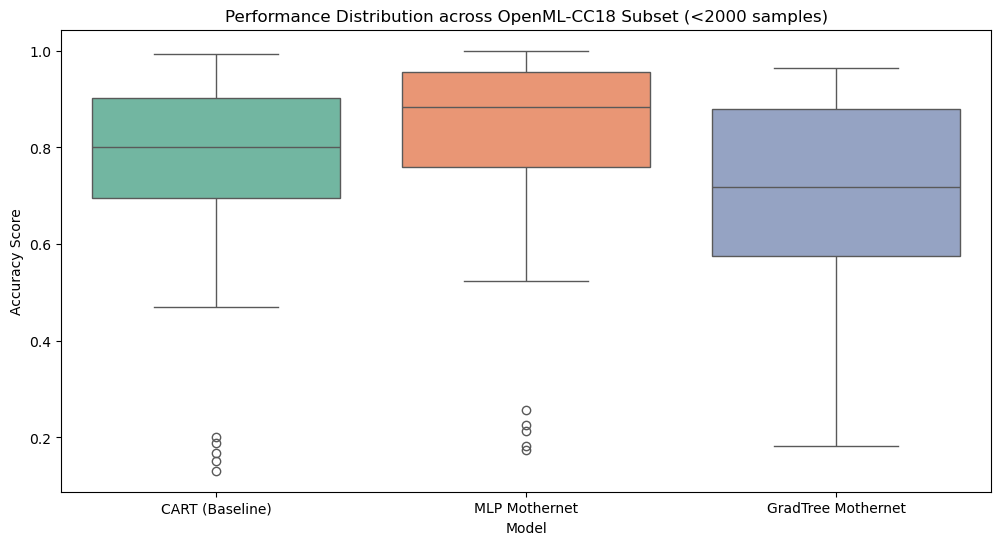


Mean AUC per Dataset:
Model                             CART (Baseline)  GradTree Mothernet  \
Dataset                                                                 
MiceProtein                              0.903312            0.636520   
analcatdata_authorship                   0.950545            0.850868   
analcatdata_dmft                         0.511285            0.513259   
balance-scale                            0.724680            0.882735   
banknote-authentication                  0.984247            0.959531   
blood-transfusion-service-center         0.571484            0.749965   
breast-w                                 0.924380            0.991700   
car                                      0.950381            0.869570   
climate-model-simulation-crashes         0.748848            0.871543   
cmc                                      0.601712            0.629873   
cnae-9                                   0.923438                 NaN   
credit-approval             

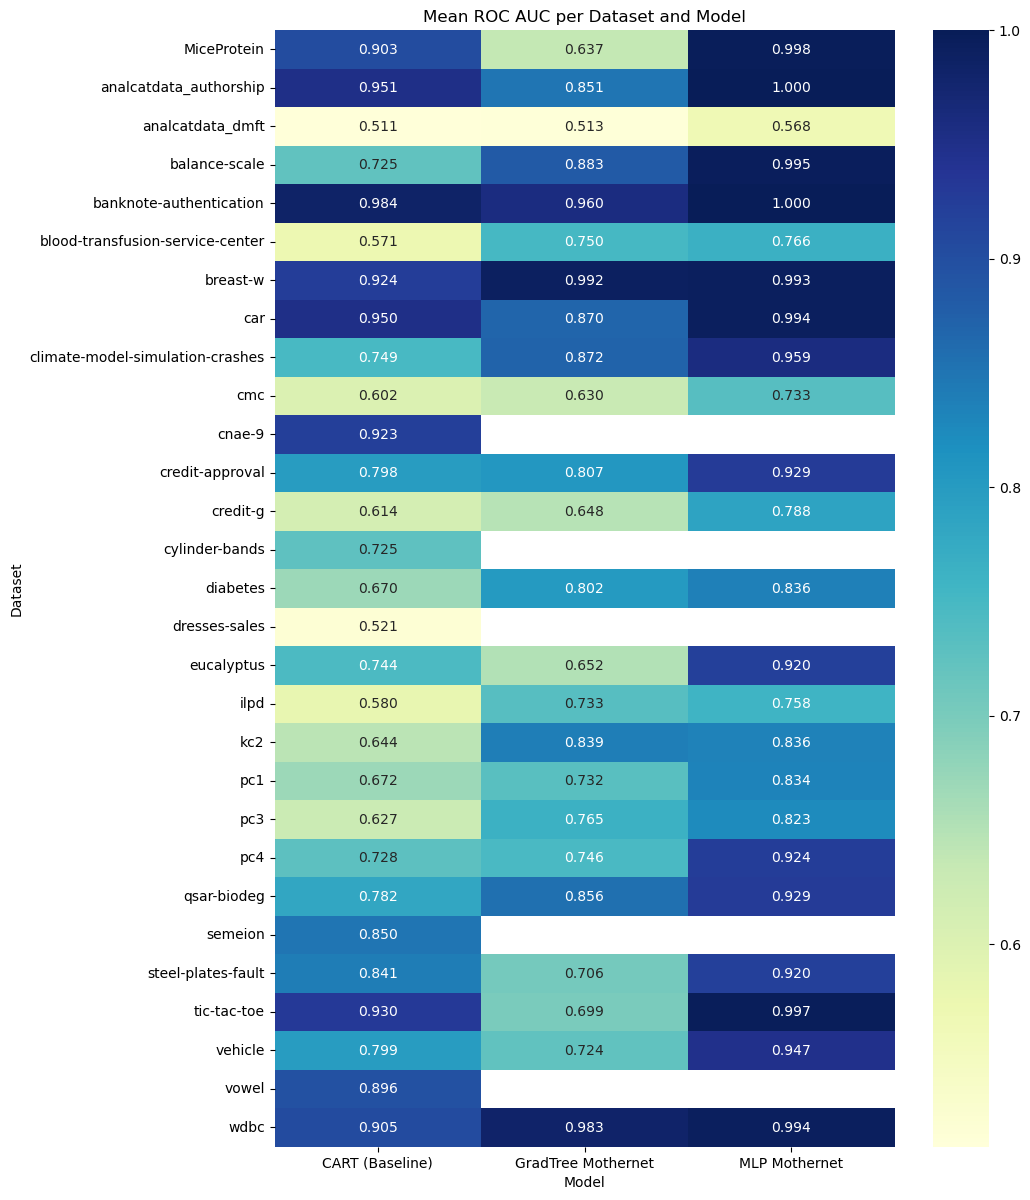

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

if not df_results.empty:
    plt.figure(figsize=(12, 6))
    # Visualize ROC AUC
    subset = df_results[['Model', 'accuracy']]
    
    # Boxplot shows distribution across ALL datasets and folds
    sns.boxplot(data=subset, x='Model', y='accuracy', palette="Set2")
    
    plt.title(f"Performance Distribution across OpenML-CC18 Subset (<{MAX_SAMPLES} samples)")
    plt.ylabel("Accuracy Score")
    plt.show()
    
    # Optional: Per-Dataset Heatmap (Win/Loss)
    pivot = df_results.pivot_table(index='Dataset', columns='Model', values='roc_auc')
    print("\nMean AUC per Dataset:")
    print(pivot)

    # Heatmap
    plt.figure(figsize=(10, len(pivot)*0.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title("Mean ROC AUC per Dataset and Model")
    plt.show()